=> Exploratory Data Analysis (EDA)

 Exploratory Data Analysis of Churn Modelling Dataset

1: Dataset Selection, Loading & Initial Inspection
   
       Objective : Understand dataset structure, size, columns, and data types.
       Following Steps : * Load dataset
                         * Understand its structure
                         * Check shape & columns
                         * Check data types

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df=pd.read_csv(r"C:\Users\HI\Documents\makbig tasks\Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info

<bound method DataFrame.info of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfP

In [31]:
df.describe()

,Credit_Score,Age,Tenure,Balance,Num_Products,Has_CreditCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


* Dataset contains 10,000 rows and 14 columns.
* Contains customer demographic and banking information.
* Target variable: Exited.

2: Data Cleaning
   * Check Missing Values
   * Check Duplicates
   * Remove Unnecessary Columns
   * Rename Columns

In [8]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [9]:
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [10]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.rename(columns={
    'CreditScore':'Credit_Score',
    'NumOfProducts':'Num_Products',
    'HasCrCard':'Has_CreditCard'
}, inplace=True)

In [13]:
df.describe()

,Credit_Score,Age,Tenure,Balance,Num_Products,Has_CreditCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
=> No missing values,
   No duplicate records,
   Removed identifier columns.

3: Descriptive Statistics
    * Summary Statistics
    * Categorical Analysis
      

In [14]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [15]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [16]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

=> Most customers belong to France.
   Majority of customers have not exited.
   Gender distribution is nearly balanced.

4: Univariate Analysis

1 Age Distribution

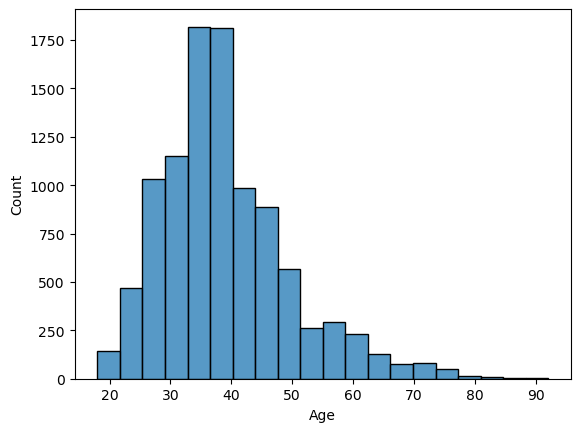

In [17]:
sns.histplot(df['Age'], bins=20)
plt.show()

2 Credit Score Distribution

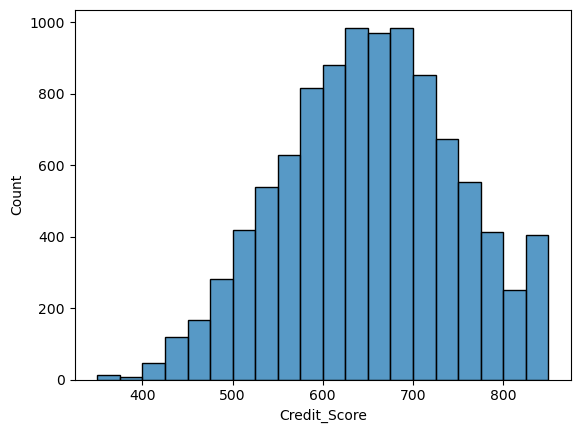

In [18]:
sns.histplot(df['Credit_Score'], bins=20)
plt.show()

3 Balance Distribution

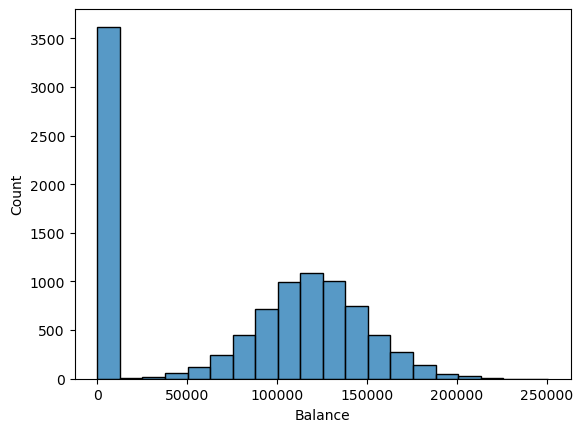

In [19]:
sns.histplot(df['Balance'], bins=20)
plt.show()

4 Age Boxplot

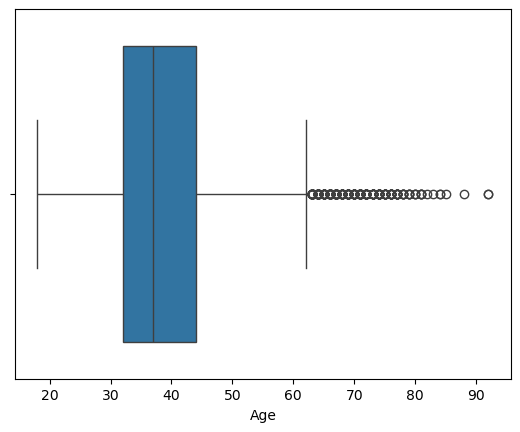

In [20]:
sns.boxplot(x=df['Age'])
plt.show()

5 Balance Boxplot

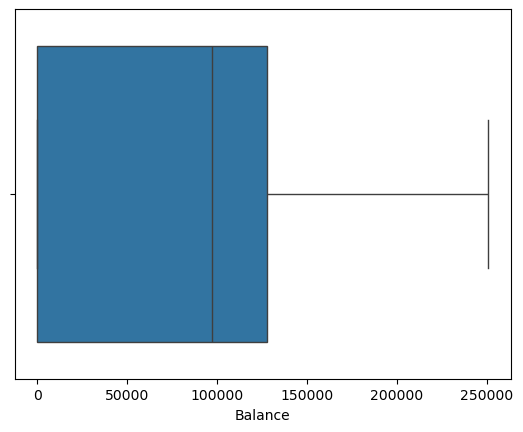

In [21]:
sns.boxplot(x=df['Balance'])
plt.show()

=> Age contains outliers.
   Balance distribution is skewed.

5: Bivariate Analysis

1 Correlation Heatmap

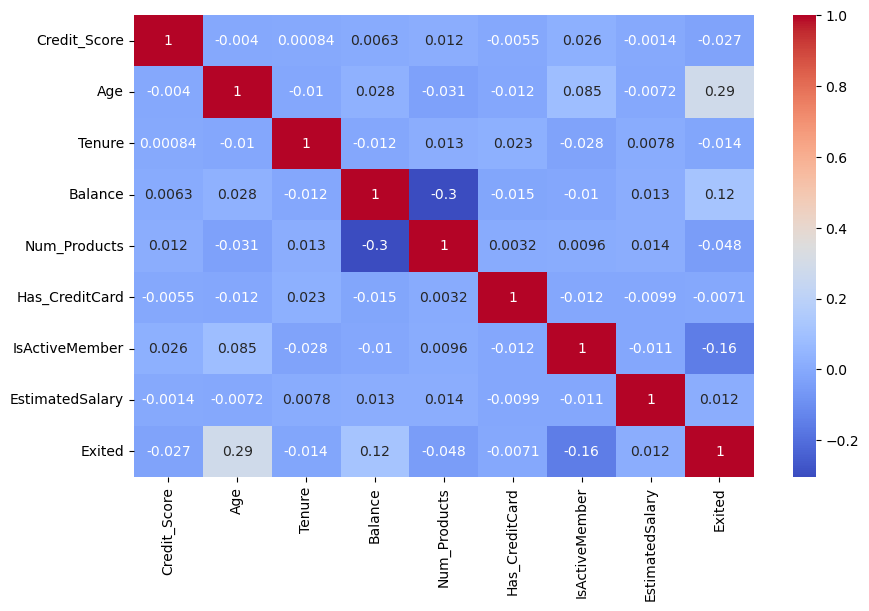

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

 2 Age vs Balance

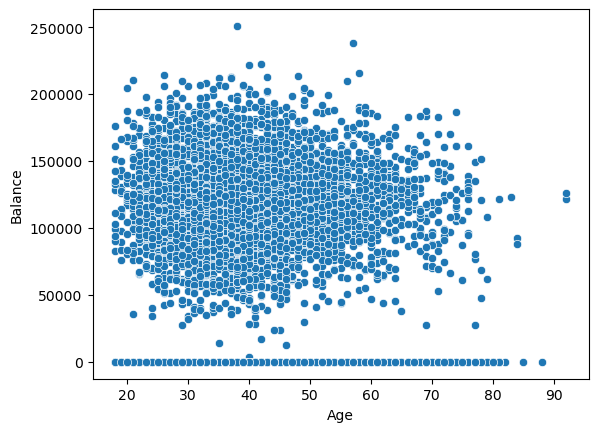

In [23]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Balance'
)

plt.show()

 3 Churn by Gender

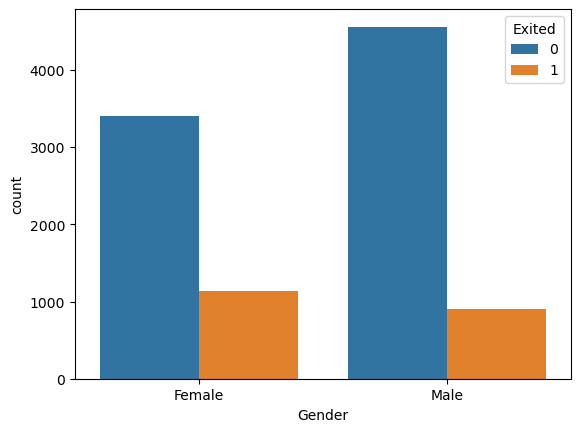

In [24]:
sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.show()

4 Churn by Geography

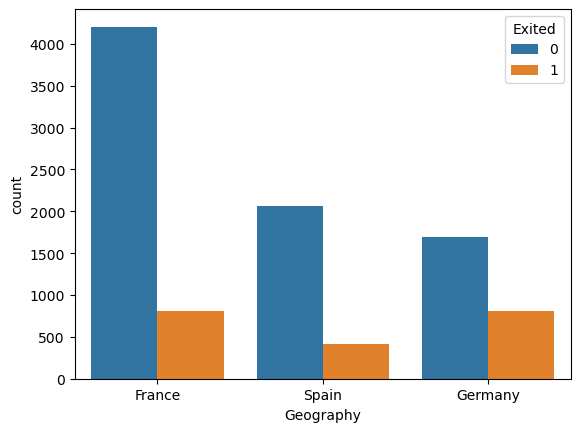

In [25]:
sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.show()

4 Average Balance by Geography

In [26]:
df.groupby('Geography')['Balance'].mean()

Geography
France      62092.636516
Germany    119730.116134
Spain       61818.147763
Name: Balance, dtype: float64

=> Germany shows higher churn rate,
   Older customers tend to churn more.

6: Advanced Exploration

Feature Engineering

1  Create Age Groups

In [32]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18,30,40,50,100],
    labels=['Young','Adult','Middle','Senior']
)

2 Churn by Age Group

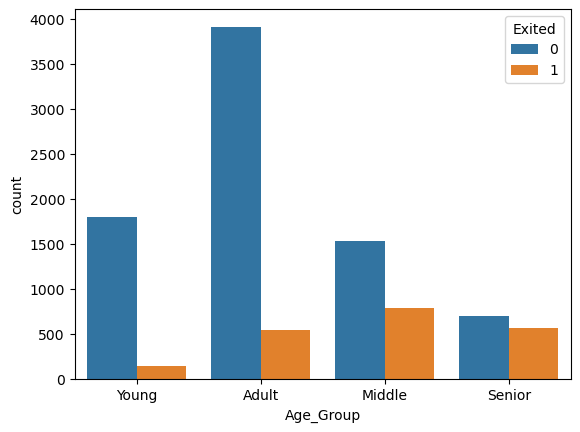

In [28]:
sns.countplot(
    x='Age_Group',
    hue='Exited',
    data=df
)

plt.show()

3 Churn Percentage

In [29]:
churn_rate = (
    df.groupby('Geography')['Exited']
    .mean()*100
)

print(churn_rate)


Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


4 Active vs Inactive Members

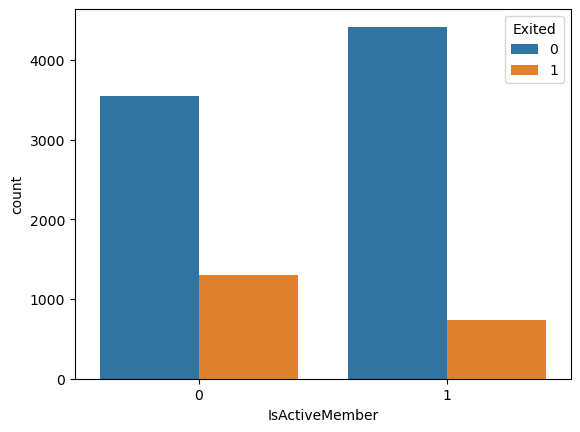

In [30]:
sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=df
)

plt.show()

=> Inactive customers churn more.
   Senior customers show higher churn.

7: Documentation & Insights

Analyze customer churn behavior and identify factors affecting customer retention.

Key Insights
1  Customers from Germany exhibit the highest churn rate.
2  Inactive members are significantly more likely to exit.
3  Customers aged above 40 show higher churn probability.
4  Customers with higher balances tend to churn more frequently.
5  Tenure alone does not strongly influence churn.

Business Recommendations

* Improve retention campaigns for inactive customers.
* Offer loyalty programs for high-balance customers.
* Focus on customer engagement in high-churn regions.
* Develop age-specific retention strategies.